In [1]:
from flowtorch.data import FOAMDataloader
from flowtorch.analysis import SVD
from flowtorch.analysis.hodmd import _create_time_delays
from pydmd import DMDc
from scipy.interpolate import interp1d
from pandas import read_csv
import torch as pt
import numpy as np
import matplotlib.pyplot as plt
import os
plt.rcParams["figure.dpi"] = 160

Refer to the installation instructions at https://github.com/FlowModelingControl/flowtorch
If you are not using the TecplotDataloader, ignore this warning.


In [2]:
path = "/home/tanuj/Masters_Thesis/AFC_using_DRL_DMDc/dmdc/signal_library/cylinder2D/data/AM"
name = "AM"
loader = FOAMDataloader(path, distributed=True)
times = loader.write_times
print(f"number of snapshots: {len(times):d}")
print(f"Available fields: {', '.join(loader.field_names[times[0]])}")

number of snapshots: 1201
Available fields: p, U


In [3]:

omega = read_csv(path+ "/omega.csv")
times_num = np.asarray([float(t_i) for t_i in times])
omega_interp = interp1d(omega.time, omega.omega, kind="linear", fill_value="extrapolate")
omega_sim = pt.from_numpy(omega_interp(times_num))

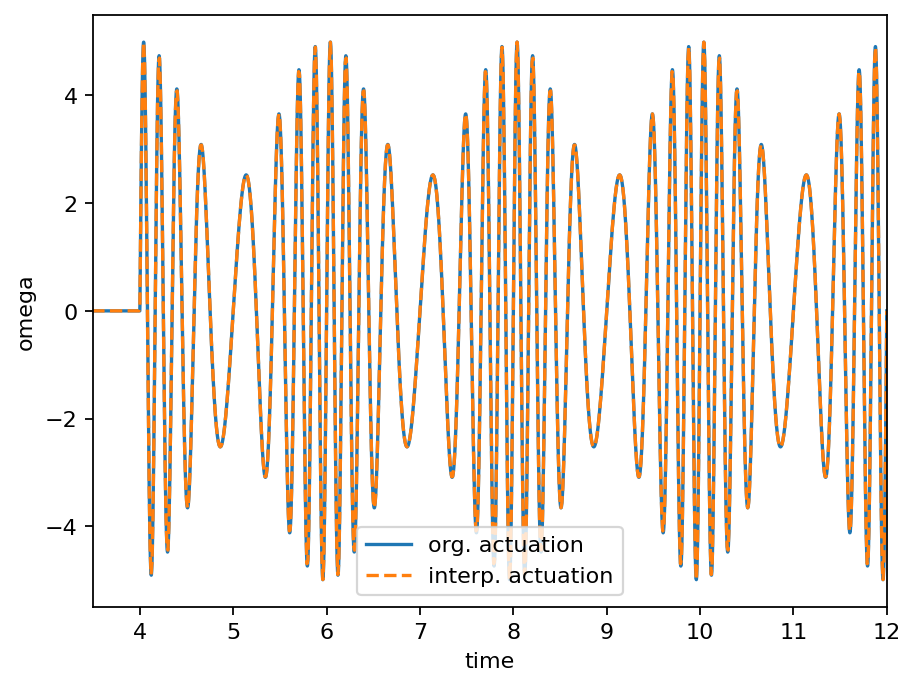

In [4]:
plt.plot(omega.time, omega.omega, label="org. actuation")
plt.plot(times_num, omega_sim, ls="--", label="interp. actuation")
plt.legend()
plt.xlabel("time")
plt.ylabel("omega")
plt.xlim(3.5, 12)
plt.show()

In [5]:
times_train = [t_i for t_i in times if 4.0 <= float(t_i) < 9.0]
times_test = [t_i for t_i in times if float(t_i) >= 9.0]
print(len(times_train), len(times_test))

500 301


In [6]:
U_train, p_train = loader.load_snapshot(["U", "p"], times_train)
print(U_train.shape, p_train.shape)

torch.Size([21250, 3, 500]) torch.Size([21250, 500])


In [7]:
dm_train = pt.cat((p_train, U_train[:, 0], U_train[:, 1]), dim=0)
dm_train.shape

torch.Size([63750, 500])

In [8]:
U_test, p_test = loader.load_snapshot(["U", "p"], times_test)
print(U_test.shape, p_test.shape)

torch.Size([21250, 3, 301]) torch.Size([21250, 301])


In [9]:
dm_test = pt.cat((p_test, U_test[:, 0], U_test[:, 1]), dim=0)
dm_test.shape

torch.Size([63750, 301])

In [10]:
svd = SVD(dm_train, rank=len(times_train))
print(svd)

SVD of a 63750x500 data matrix
Selected/optimal rank: 500/232
data type: torch.float32 (4b)
truncated SVD size: 122.5491Mb


In [11]:
def compute_projection_error(dm, U, rank):
    Ur = U[:, :rank]
    return (dm - Ur @ (Ur.T @ dm)).norm(dim=0) / dm.norm(dim=0)

In [12]:
ranks = [10, 30, 50, 75, 100, 150]

In [13]:
pro_err_train = [compute_projection_error(dm_train, svd.U, r) for r in ranks]
pro_err_test = [compute_projection_error(dm_test, svd.U, r) for r in ranks]

In [14]:
times_train_num = pt.tensor([float(t_i) for t_i in times_train])
times_test_num = pt.tensor([float(t_i) for t_i in times_test])

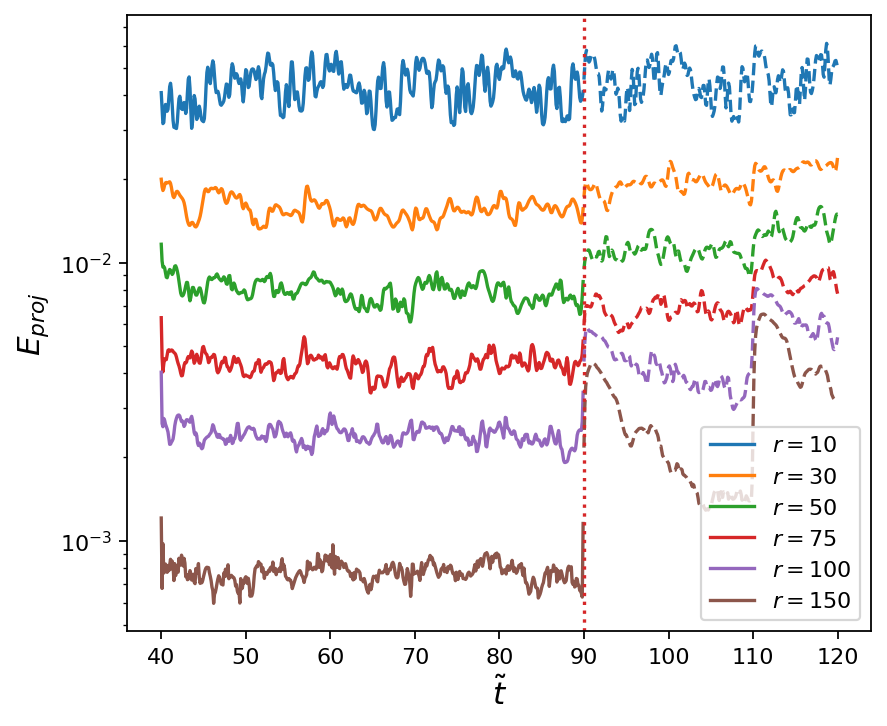

In [15]:
plt.figure(figsize = (6, 5), dpi = 160)

for i, r in enumerate(ranks):
    plt.plot(times_train_num*10, pro_err_train[i], c=f"C{i}", label=rf"$r={r:d}$")
    plt.plot(times_test_num*10, pro_err_test[i], c=f"C{i}", ls="--")
plt.axvline(times_test_num[0]*10, ls=":", c="C3")
plt.xlabel(r"$\tilde{t}$", fontsize = 14)
plt.ylabel(r"$E_{proj}$", fontsize = 14)
plt.legend()
plt.yscale("log")
plt.savefig(f"{name}_proj.png", bbox_inches="tight")
plt.show()

In [16]:
pro_err_mean_train = [e.mean() for e in pro_err_train]
pro_err_mean_test = [e.mean() for e in pro_err_test]

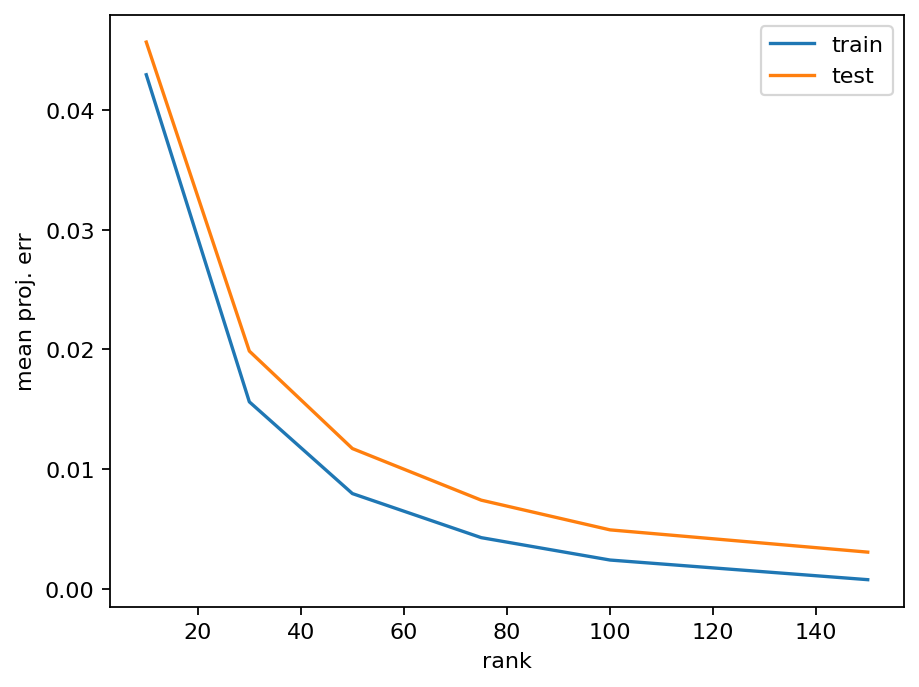

In [17]:
plt.plot(ranks, pro_err_mean_train, label="train")
plt.plot(ranks, pro_err_mean_test, label="test")
plt.xlabel("rank")
plt.ylabel("mean proj. err")
plt.legend()
plt.show()

In [18]:
rank = 60
coeffs_train = svd.U[:, :rank].T @ dm_train
coeffs_test = svd.U[:, :rank].T @ dm_test
omega_train = pt.from_numpy(omega_interp(times_train_num)).type(coeffs_train.dtype)
omega_test = pt.from_numpy(omega_interp(times_test_num)).type(coeffs_test.dtype)

In [19]:
def fit_dmdc_model(dm, omega, rank):
    dmd = DMDc(svd_rank=rank)
    dmd.fit(dm.numpy(), omega.numpy())
    A = pt.from_numpy(dmd._Atilde._Atilde)
    B = pt.from_numpy(dmd.basis.T @ dmd.B)
    basis = pt.from_numpy(dmd.basis)
    return A.real.type(dm.dtype), B.real.type(dm.dtype), basis.real.type(dm.dtype)

In [20]:
A_train, B_train, basis_train = fit_dmdc_model(coeffs_train, omega_train[:-1], rank)

In [21]:
def model_rollout(x0, control, A, B, basis):

    x0 = basis.T @ x0
    M, N = x0.shape[0], control.shape[-1]
    pred = pt.empty((M, N))
    if len(control.shape) == 1:
        pred[:, 0] = A @ x0 + B[:, 0] * control[0]
        for i in range(1, N):
            pred[:, i] = A @ pred[:, i-1] + B[:, 0] * control[i-1]
    else:
        pred[:, 0] = A @ x0 + B @ control[:, 0]
        for i in range(1, N):
            pred[:, i] = A @ pred[:, i-1] + B @ control[:, i-1]
    pred = basis @ pred
    return pred

In [22]:
pred_train = model_rollout(coeffs_train[:, 0], omega_train[:-1], A_train, B_train, basis_train)
pred_train.shape

torch.Size([60, 499])

In [23]:
X_train_pred_0 = svd.U[:,:rank] @ pred_train
X_train_true_0 = dm_train[:, -X_train_pred_0.shape[1]:]


In [24]:
(pred_train - coeffs_train[:, 1:]).norm() / coeffs_train[:, 1:].norm()

tensor(0.0834)

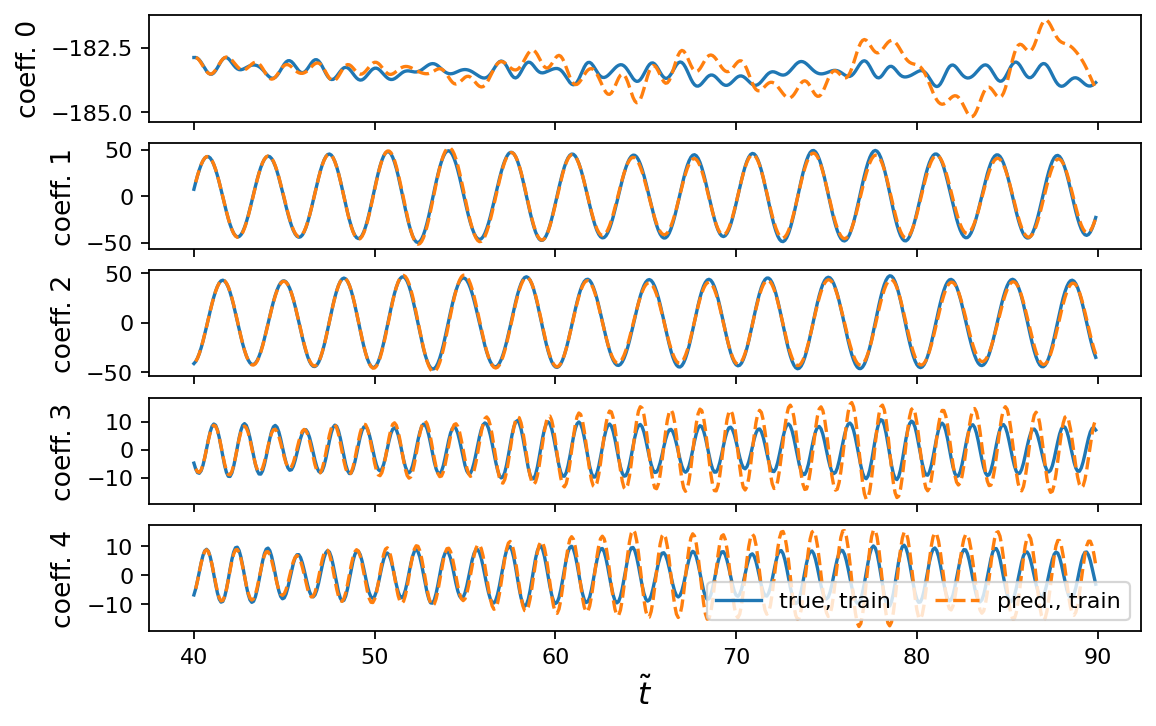

In [25]:
n_show = 5
fig, axarr = plt.subplots(n_show, figsize=(8, n_show), sharex=True)
for i in range(n_show):
    axarr[i].plot(times_train_num*10, coeffs_train[i], label="true, train")
    axarr[i].plot(times_train_num[1:]*10, pred_train[i], ls="--", label="pred., train")
    axarr[i].set_ylabel(f"coeff. {i}", fontsize = 12)
axarr[-1].legend(ncol=2, loc = "lower right")
axarr[-1].set_xlabel(r"$\tilde{t}$", fontsize = 14)
plt.savefig(f"{name}_q_0_train.png", bbox_inches="tight")
plt.show()

In [26]:
pred_test = model_rollout(coeffs_test[:, 0], omega_test[:-1], A_train, B_train, basis_train)
pred_test.shape

torch.Size([60, 300])

In [27]:
X_test_pred_0 = svd.U[:,:rank] @ pred_test
X_test_true_0 = dm_test[:, -X_test_pred_0.shape[1]:]

In [28]:
(pred_test - coeffs_test[:, 1:]).norm() / coeffs_test[:, 1:].norm()

tensor(0.0461)

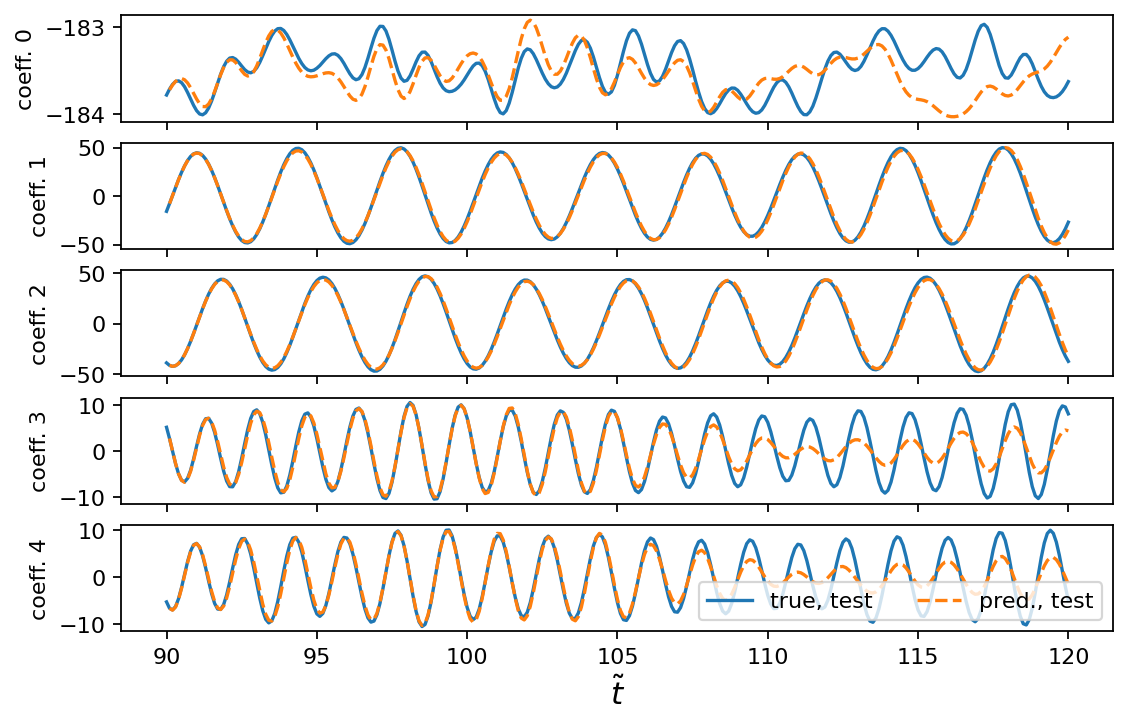

In [29]:
n_show = 5
fig, axarr = plt.subplots(n_show, figsize=(8, n_show), sharex=True)
for i in range(n_show):
    axarr[i].plot(times_test_num*10, coeffs_test[i], label="true, test")
    axarr[i].plot(times_test_num[1:]*10, pred_test[i], ls="--", label="pred., test")
    axarr[i].set_ylabel(f"coeff. {i}")
axarr[-1].legend(ncol=2, loc = "lower right")
axarr[-1].set_xlabel(r"$\tilde{t}$", fontsize = 14)
plt.savefig(f"{name}_q_0_test.png", bbox_inches="tight")
plt.show()

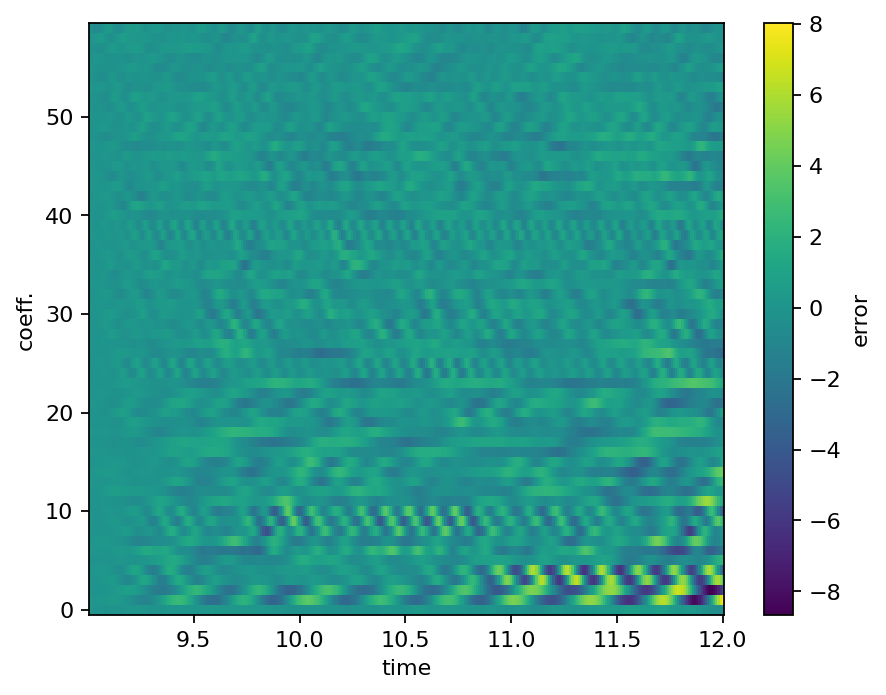

In [30]:
cont = plt.pcolormesh(times_test_num[1:], list(range(rank)), coeffs_test[:, 1:] - pred_test)
cbar = plt.colorbar(cont, label="error")
plt.xlabel("time")
plt.ylabel("coeff.")
plt.show()

In [31]:
delay = 100
coeffs_delay_train = _create_time_delays(coeffs_train, delay)
omega_delay_train = _create_time_delays(omega_train.unsqueeze(0), delay)
coeffs_delay_train.shape, omega_delay_train.shape

(torch.Size([6000, 401]), torch.Size([100, 401]))

In [32]:
A_delay_train, B_delay_train, basis_delay_train = fit_dmdc_model(coeffs_delay_train, omega_delay_train[:, :-1], rank)
A_delay_train.shape, B_delay_train.shape

/home/tanuj/Masters_Thesis/AFC_using_DRL_DMDc/env/lib/python3.12/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 2631066.0. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


(torch.Size([60, 60]), torch.Size([60, 100]))

In [33]:
pred_delay_train = model_rollout(coeffs_delay_train[:, 0], omega_delay_train[:, :-1], A_delay_train, B_delay_train, basis_delay_train)
pred_delay_train.shape

torch.Size([6000, 400])

In [34]:
X_train_pred_100 = svd.U[:,:rank] @ pred_delay_train[(delay-1)*rank:, :]
X_train_true_100 = dm_train[:, -X_train_pred_100.shape[1]:]

In [35]:
(pred_delay_train[(delay-1)*rank:, :] - coeffs_train[:, delay:]).norm() / coeffs_train[:, delay:].norm()

tensor(0.0276)

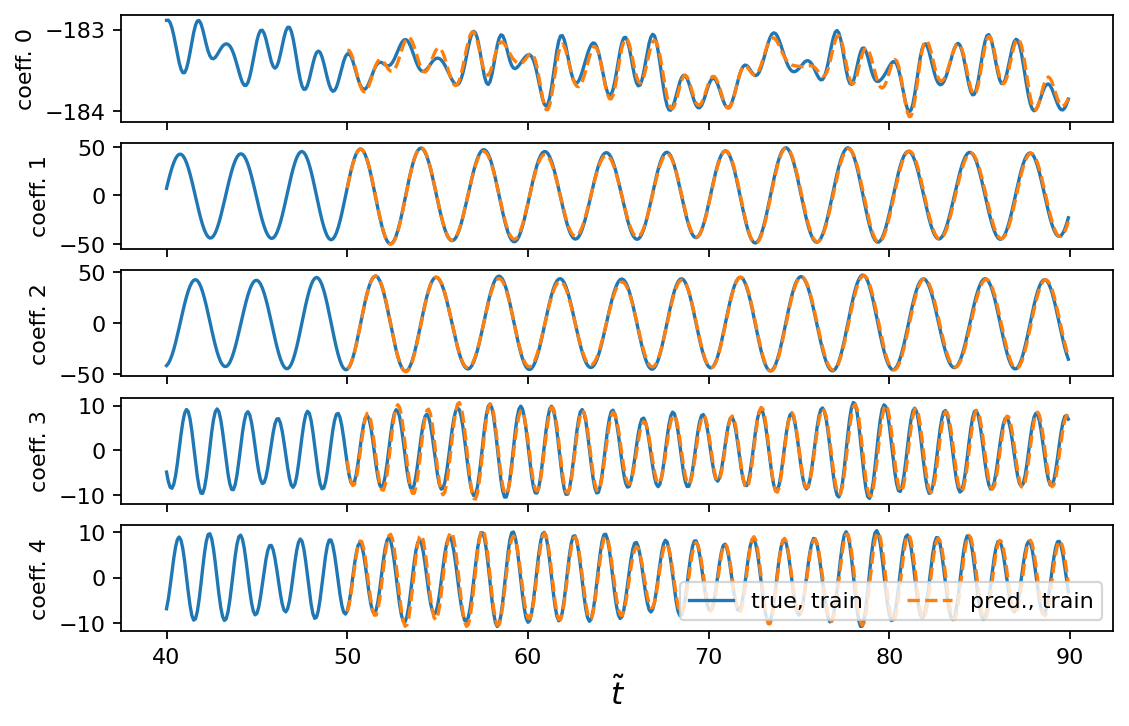

In [36]:
n_show = 5
fig, axarr = plt.subplots(n_show, figsize=(8, n_show), sharex=True)
for i in range(n_show):
    axarr[i].plot(times_train_num*10, coeffs_train[i], label="true, train")
    axarr[i].plot(times_train_num[delay:]*10, pred_delay_train[(delay-1)*rank+i], ls="--", label="pred., train")
    axarr[i].set_ylabel(f"coeff. {i}")
axarr[-1].legend(ncol=2, loc = "lower right")
axarr[-1].set_xlabel(r"$\tilde{t}$", fontsize = 14)
plt.savefig(f"{name}_q_100_train.png", bbox_inches="tight")
plt.show()

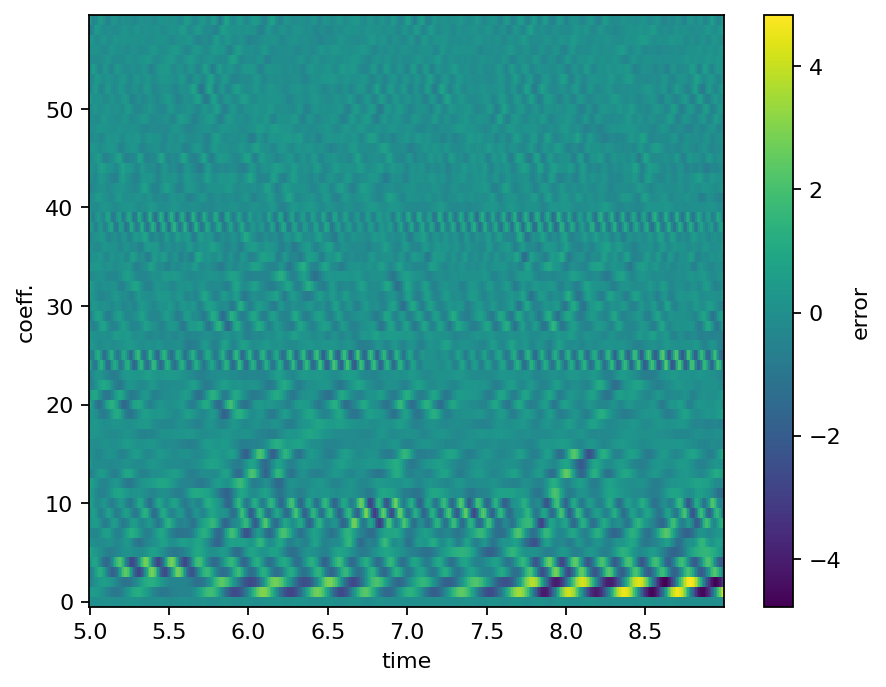

In [37]:
cont = plt.pcolormesh(times_train_num[delay:], list(range(rank)), coeffs_train[:, delay:] - pred_delay_train[(delay-1)*rank:, :])
cbar = plt.colorbar(cont, label="error")
plt.xlabel("time")
plt.ylabel("coeff.")
plt.show()

In [38]:
coeffs_delay_test = _create_time_delays(coeffs_test, delay)
omega_delay_test = _create_time_delays(omega_test.unsqueeze(0), delay)
coeffs_delay_test.shape, omega_delay_test.shape

(torch.Size([6000, 202]), torch.Size([100, 202]))

In [39]:
pred_delay_test = model_rollout(coeffs_delay_test[:, 0], omega_delay_test[:, :-1], A_delay_train, B_delay_train, basis_delay_train)
pred_delay_test.shape

torch.Size([6000, 201])

In [40]:
X_test_pred_100 = svd.U[:,:rank] @ pred_delay_test[-rank:, :]
X_test_true_100 = dm_test[:, -X_test_pred_100.shape[1]:]

In [41]:
(pred_delay_test[(delay-1)*rank:, :] - coeffs_test[:, delay:]).norm() / coeffs_test[:, delay:].norm()

tensor(0.0353)

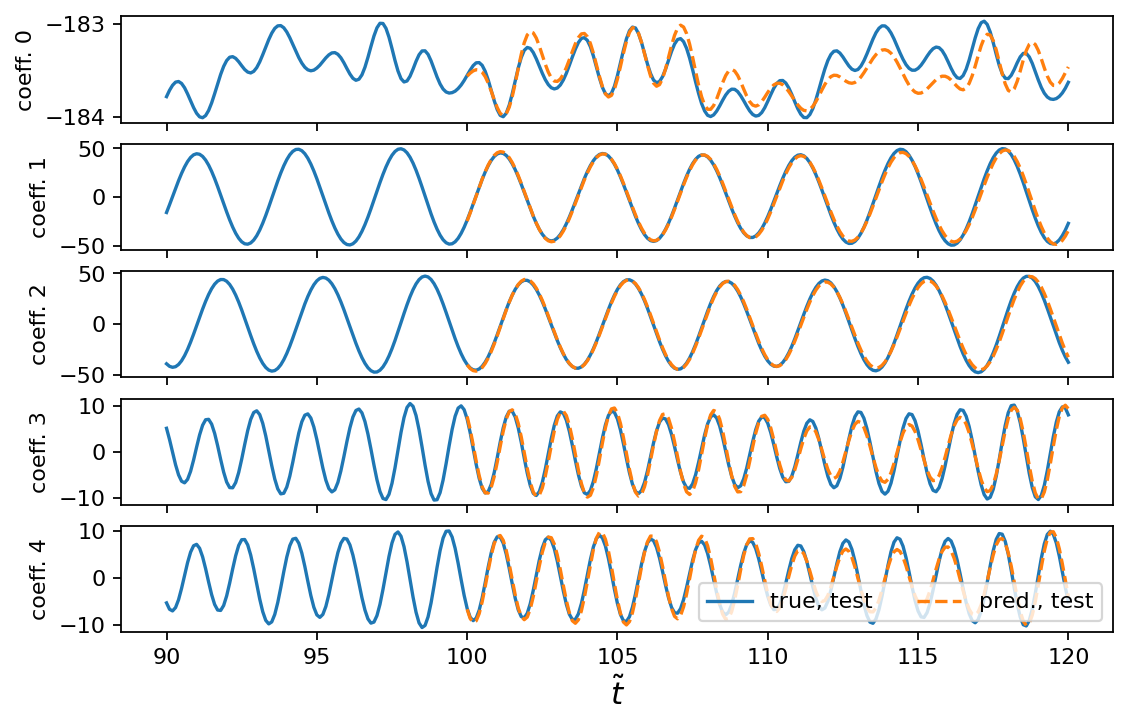

In [42]:
n_show = 5
fig, axarr = plt.subplots(n_show, figsize=(8, n_show), sharex=True)
for i in range(n_show):
    axarr[i].plot(times_test_num*10, coeffs_test[i], label="true, test")
    axarr[i].plot(times_test_num[delay:]*10, pred_delay_test[(delay-1)*rank+i], ls="--", label="pred., test")
    axarr[i].set_ylabel(f"coeff. {i}")
axarr[-1].legend(ncol=2, loc = "lower right")
axarr[-1].set_xlabel(r"$\tilde{t}$", fontsize = 14)
plt.savefig(f"{name}_q_100_test.png", bbox_inches="tight")
plt.show()

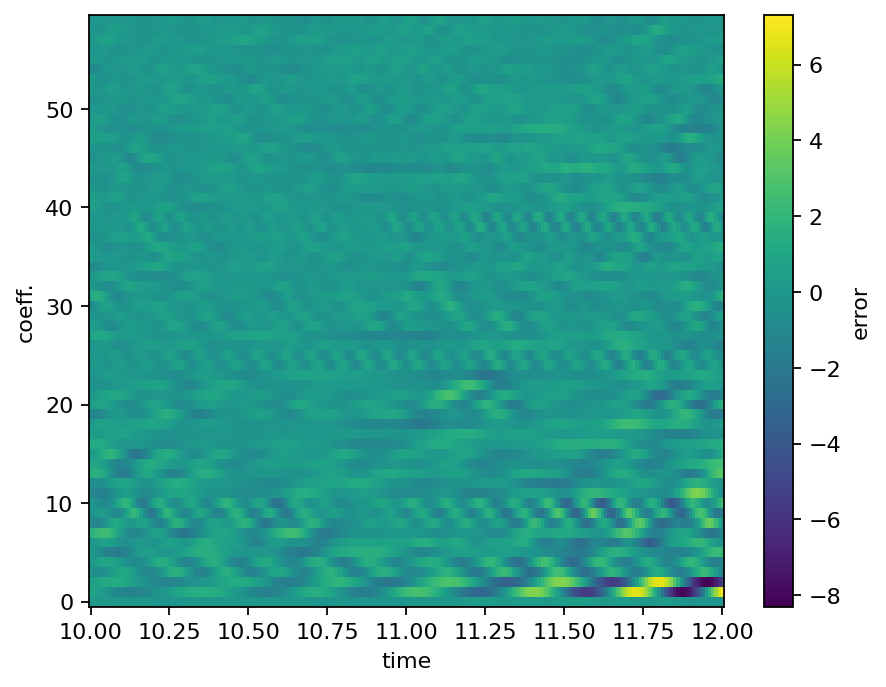

In [43]:
cont = plt.pcolormesh(times_test_num[delay:], list(range(rank)), coeffs_test[:, delay:] - pred_delay_test[(delay-1)*rank:, :])
cbar = plt.colorbar(cont, label="error")
plt.xlabel("time")
plt.ylabel("coeff.")
plt.show()

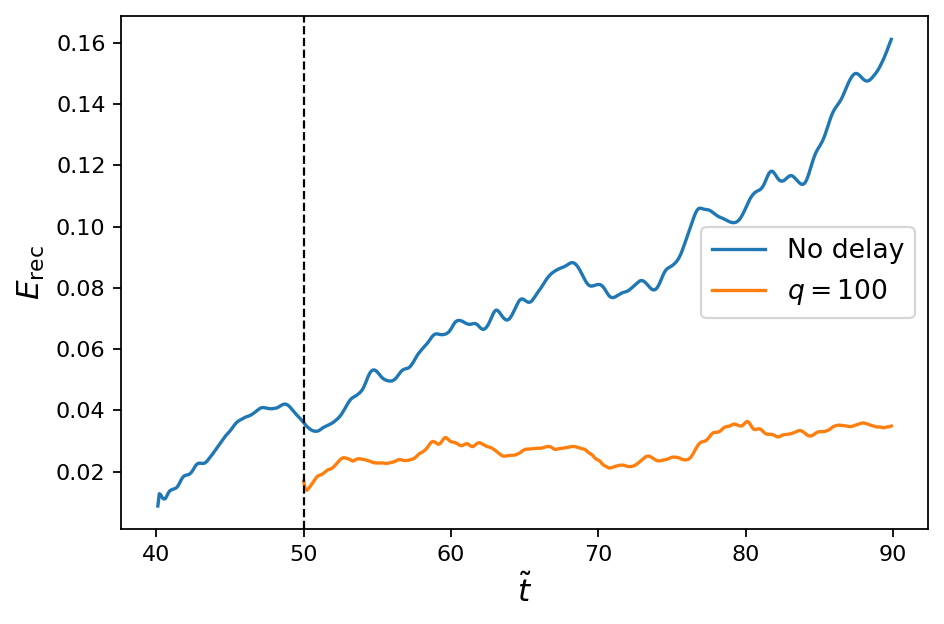

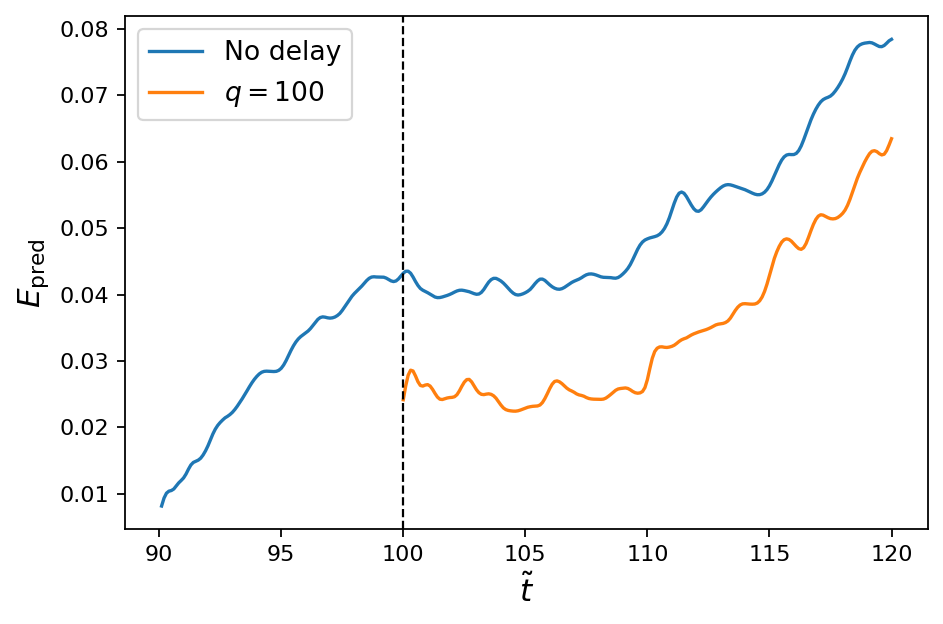

In [44]:
E_rec_0 = (X_train_pred_0 - X_train_true_0).norm(dim=0)/(X_train_true_0).norm(dim=0)
E_rec_100 = (X_train_pred_100 - X_train_true_100).norm(dim=0)/(X_train_true_100).norm(dim=0)

# Prediction (test) errors → E_pred
E_pred_0 = (X_test_pred_0 - X_test_true_0).norm(dim=0)/(X_test_true_0).norm(dim=0)
E_pred_100 = (X_test_pred_100 - X_test_true_100).norm(dim=0)/(X_test_true_100).norm(dim=0)

# Convert to numpy
E_rec_0 = E_rec_0.detach().cpu().numpy()
E_rec_100 = E_rec_100.detach().cpu().numpy()
E_pred_0 = E_pred_0.detach().cpu().numpy()
E_pred_100 = E_pred_100.detach().cpu().numpy()

# Time vectors (adapt if you already have physical time arrays)

# ======================================================
# 1) Reconstruction error E_rec (training)
# ======================================================
plt.figure(figsize=(6, 4), dpi = 160)
plt.plot(times_train_num[-len(E_rec_0):]*10, E_rec_0, label=r"No delay")
plt.plot(times_train_num[-len(E_rec_100):]*10, E_rec_100, label=r"$q = 100$")
plt.xlabel(r"$\tilde{t}$", fontsize = 14)
plt.ylabel(r"$E_{\mathrm{rec}}$", fontsize = 14)
plt.legend(fontsize = 12)
plt.tight_layout()
plt.axvline(x=times_train_num[-len(E_rec_100)]*10, color='k', linestyle='--', linewidth=1)
plt.savefig(f"Erec_{name}.png", bbox_inches="tight")

# ======================================================
# 2) Prediction error E_pred (testing)
# ======================================================
plt.figure(figsize=(6, 4))
plt.plot(times_test_num[-len(E_pred_0):]*10, E_pred_0, label=r"No delay")
plt.plot(times_test_num[-len(E_pred_100):]*10, E_pred_100, label=r"$q = 100$")
plt.xlabel(r"$\tilde{t}$", fontsize = 14)
plt.ylabel(r"$E_{\mathrm{pred}}$", fontsize = 14)
plt.legend( fontsize = 12)
plt.tight_layout()
plt.axvline(x=times_test_num[-len(E_pred_100)]*10, color='k', linestyle='--', linewidth=1)
plt.savefig(f"Epred_{name}.png", bbox_inches="tight")
plt.show()